In [1]:
"""
Script to visualize pseudobulk splicing PSI data from the long format file
"""

# Load packages we need
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Set, Dict, Any, Optional
from scipy import stats
from sklearn.decomposition import PCA
import gffutils
import random

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper # type: ignore
from leafletfa_utils.atseviz.main import * # type: ignore
print("Imports successful!")

# ----- Configuration -----

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Output directory
output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Timestamp for file naming
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!
Output directory: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations


In [2]:
# ----- Load data -----
pseudobulk_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/pseudobulk_final_broad_cell_type_20250623_171456.csv.gz"
print(f"Loading pseudobulk data from: {pseudobulk_file}")
long_df = pd.read_csv(pseudobulk_file, low_memory=False)
print(f"Loaded {len(long_df)} rows of data with {long_df['cell_type'].nunique()} cell types")

# Load ATSE data
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/stella_gtf/TMS_atse_file_unanno_also_2025-05-11_06-23-05.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"Loaded {len(atses)} rows of ATSE data with {len(atses['event_id'].unique())} unique events")

# Load human DB file if available
try:
    db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/hg38_stella_gtf"
    db = gffutils.FeatureDB(db_file, keep_order=True)
    print("Loaded genome database successfully")
    genome_db_available = True
except Exception as e:
    print(f"Warning: Could not load genome database: {e}")
    genome_db_available = False

Loading pseudobulk data from: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/pseudobulk_final_broad_cell_type_20250623_171456.csv.gz
Loaded 12491650 rows of data with 50 cell types
Loaded 249833 rows of ATSE data with 57924 unique events
Loaded genome database successfully


#### Input: Gene ID or symbol and output: Clustermap output with all gene-junctions-ATSEs displayed PSI by major cell type group

In [ ]:
# Load Human Splicing Pseudobulk Data
pseudobulk_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/pseudobulk_final_broad_cell_type_20250623_171456.csv.gz"
print(f"Loading pseudobulk data from: {pseudobulk_file}")
long_df = pd.read_csv(pseudobulk_file, low_memory=False)

# filter rows where n_cells==0
long_df = long_df[long_df["n_cells"] > 0]

# filter rows where gene_symbol is NaN
long_df = long_df[long_df["gene_symbol"].notna()]

,cell_type,junction_id,junction_id_index,junction_count,atse_count,psi,n_cells,gene_id,event_id,gene_symbol
0,Macrophage,chrX_100635746_100636792_-,242241,0.0,41.0,0.0,2365,ENSG00000000003,ENSG00000000003.16_atse_1,TSPAN6
1,Hematopoietic_Progenitor,chrX_100635746_100636607_-,242240,197.0,197.0,1.0,286,ENSG00000000003,ENSG00000000003.16_atse_1,TSPAN6
2,Hematopoietic_Progenitor,chrX_100635746_100636190_-,242239,0.0,197.0,0.0,286,ENSG00000000003,ENSG00000000003.16_atse_1,TSPAN6
3,GI_Epithelial,chrX_100636207_100636792_-,242242,0.0,6767.0,0.0,2104,ENSG00000000003,ENSG00000000003.16_atse_1,TSPAN6
4,Plasma_cell,chrX_100636207_100636792_-,242242,0.0,374.0,0.0,991,ENSG00000000003,ENSG00000000003.16_atse_1,TSPAN6
...,...,...,...,...,...,...,...,...,...,...
12347694,Mammary_Epithelial,chr9_120845190_120847293_+,233540,0.0,0.0,NaN,51,ENSG00000293514,ENSG00000293514.1_atse_2,CUTALP
12347695,Urogenital_Epithelial,chr9_120845190_120847293_+,233540,0.0,0.0,NaN,781,ENSG00000293514,ENSG00000293514.1_atse_2,CUTALP
12347697,Mammary_Epithelial,chr9_120845196_120847293_+,233541,0.0,0.0,NaN,51,ENSG00000293514,ENSG00000293514.1_atse_2,CUTALP
12347698,Mammary_Epithelial,chr9_120845826_120847293_+,233542,0.0,0.0,NaN,51,ENSG00000293514,ENSG00000293514.1_atse_2,CUTALP


In [3]:
long_df["gene_id"] = long_df["gene_id"].str.split(".").str[0]

In [24]:
long_df["cell_type"].unique()

array(['Macrophage', 'Hematopoietic_Progenitor', 'GI_Epithelial',
       'Plasma_cell', 'Skeletal_Muscle', 'PNS_Glia', 'Myeloid_Other',
       'CD4_T_cell', 'Other_Epithelial', 'CNS_Glia', 'Pericyte',
       'Stem_Progenitor_Other', 'Venous_Endothelial',
       'Arterial_Endothelial', 'B_cell', 'Secretory_Gland',
       'Hematopoietic_Mature', 'Immune_Other', 'Dendritic_cell',
       'Mammary_Epithelial', 'Granulocyte', 'Alveolar_cell',
       'Specialized_Endothelial', 'Smooth_Muscle', 'CD8_T_cell',
       'Inhibitory_Neuron', 'General_Fibroblast', 'Other_T_cell',
       'Monocyte', 'Excitatory_Neuron', 'Microglia', 'NK_ILC',
       'Lymphatic_Endothelial', 'Organ_Specific_Fibroblast',
       'Mesenchymal_Stem', 'Regulatory_T_cell', 'Respiratory_Epithelial',
       'Urogenital_Epithelial', 'Capillary_Endothelial'], dtype=object)

                      cell_type               junction_id  junction_id_index  \
6584200  Respiratory_Epithelial  chr8_22636962_22644754_-             227661   
6584201             Granulocyte  chr8_22636962_22644754_-             227661   
6584202      Mammary_Epithelial  chr8_22636962_22669043_-             227662   
6584203         Skeletal_Muscle  chr8_22644803_22669043_-             227663   
6584204  Respiratory_Epithelial  chr8_22644803_22669043_-             227663   
...                         ...                       ...                ...   
6585044           Smooth_Muscle  chr8_22621357_22621459_-             227648   
6585045           Smooth_Muscle  chr8_22621336_22621459_-             227647   
6585046                Monocyte  chr8_22621357_22621459_-             227648   
6585047              CD8_T_cell  chr8_22621357_22621459_-             227648   
6585048    Hematopoietic_Mature  chr8_22621357_22621459_-             227648   

         junction_count  atse_count    

/scratch/ipykernel_2561697/2959169478.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis').copy()


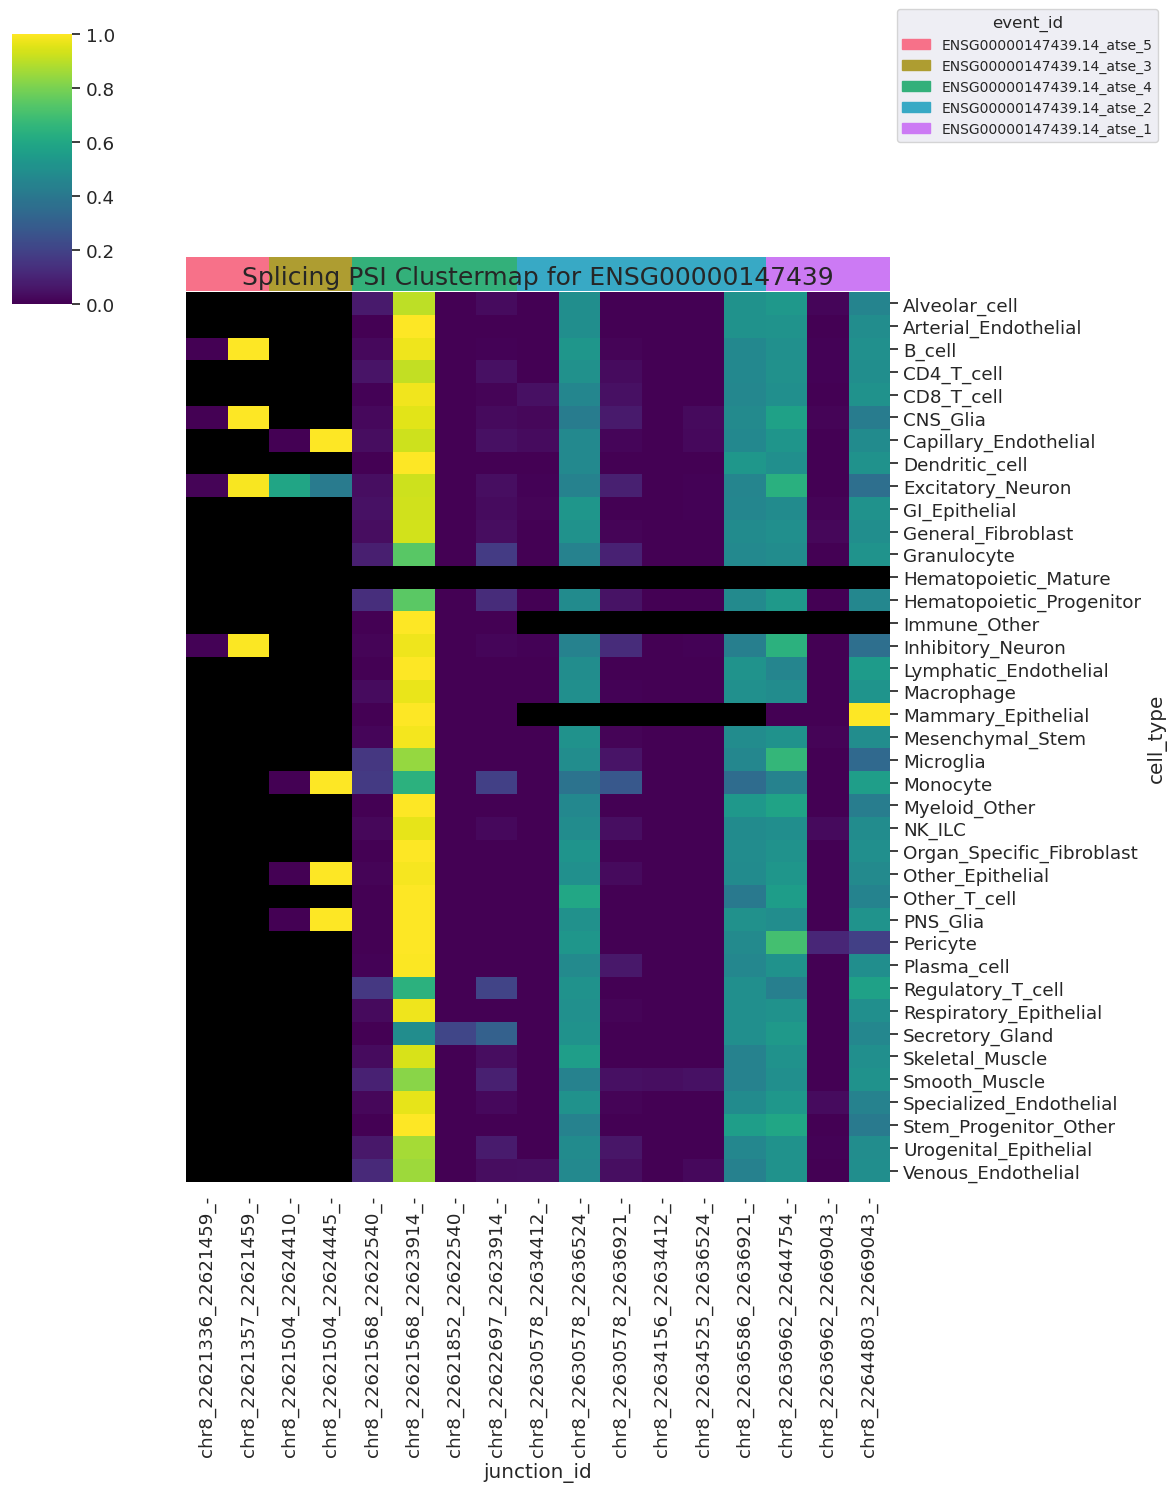

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Sample gene name from your dataset
# gene_name = np.random.choice(long_df["gene_symbol"].unique(), 1)[0]
gene_id = "ENSG00000147439"
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# --- Leave NaNs as they are, do not fill with 0 ---
# psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# --- Get the colormap and set the color for NaN values ---
# By default, seaborn uses the 'viridis' colormap. We'll make a copy and modify it.
# You can replace 'viridis' with any other colormap you prefer.
cmap = cm.get_cmap('viridis').copy()
cmap.set_bad('black')

# Generate the clustermap
g = sns.clustermap(
    psi_matrix,
    row_cluster=False,
    col_cluster=False,
    cmap=cmap,  # Use the modified colormap
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()

Processing ENSG00000147439.14_atse_1...
Found 12 transcripts for ENSG00000147439.14_atse_1
Plot saved to ENSG00000147439.14_atse_1.pdf!


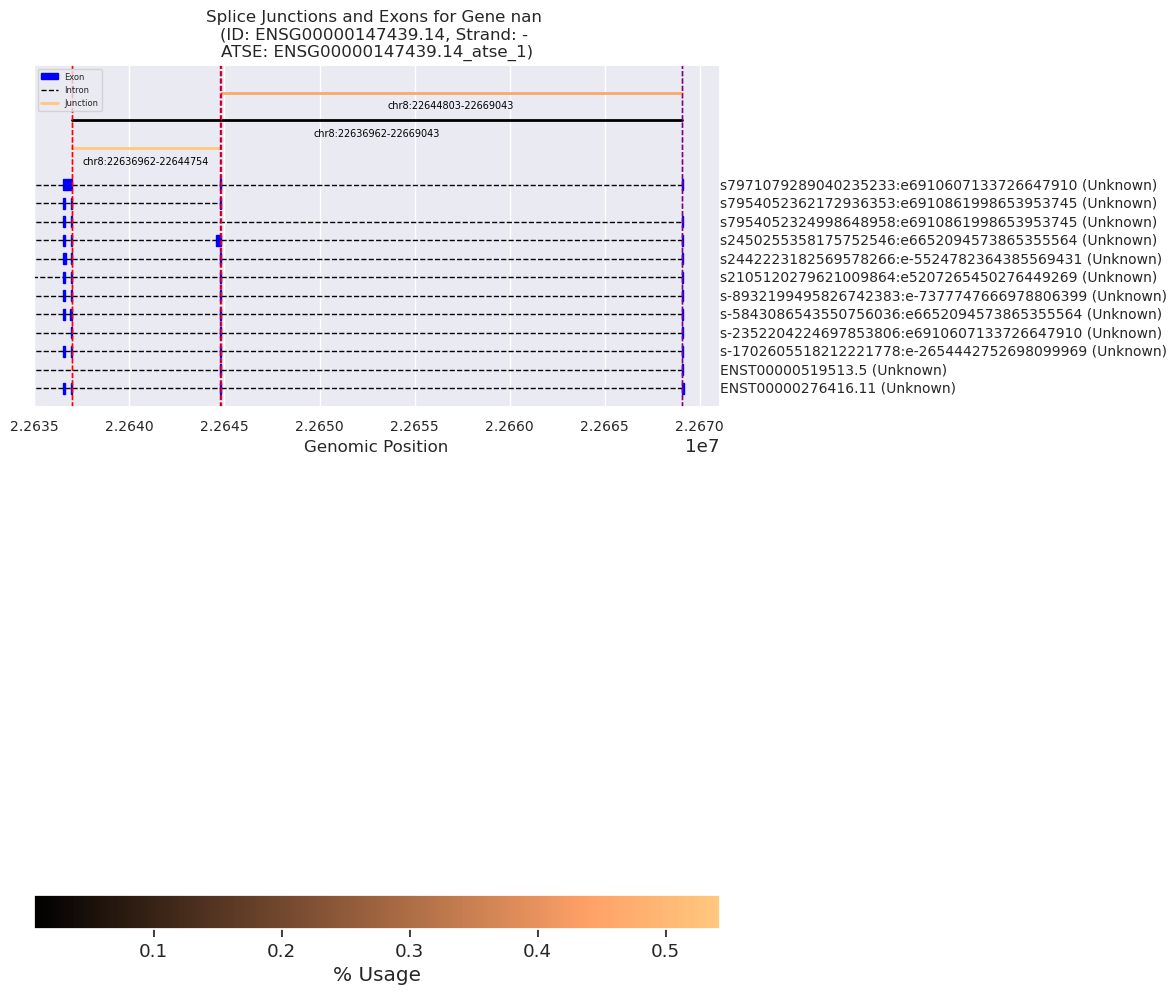

Saved plot to ENSG00000147439.14_atse_1.pdf
Processing ENSG00000147439.14_atse_2...
Found 12 transcripts for ENSG00000147439.14_atse_2
Plot saved to ENSG00000147439.14_atse_2.pdf!


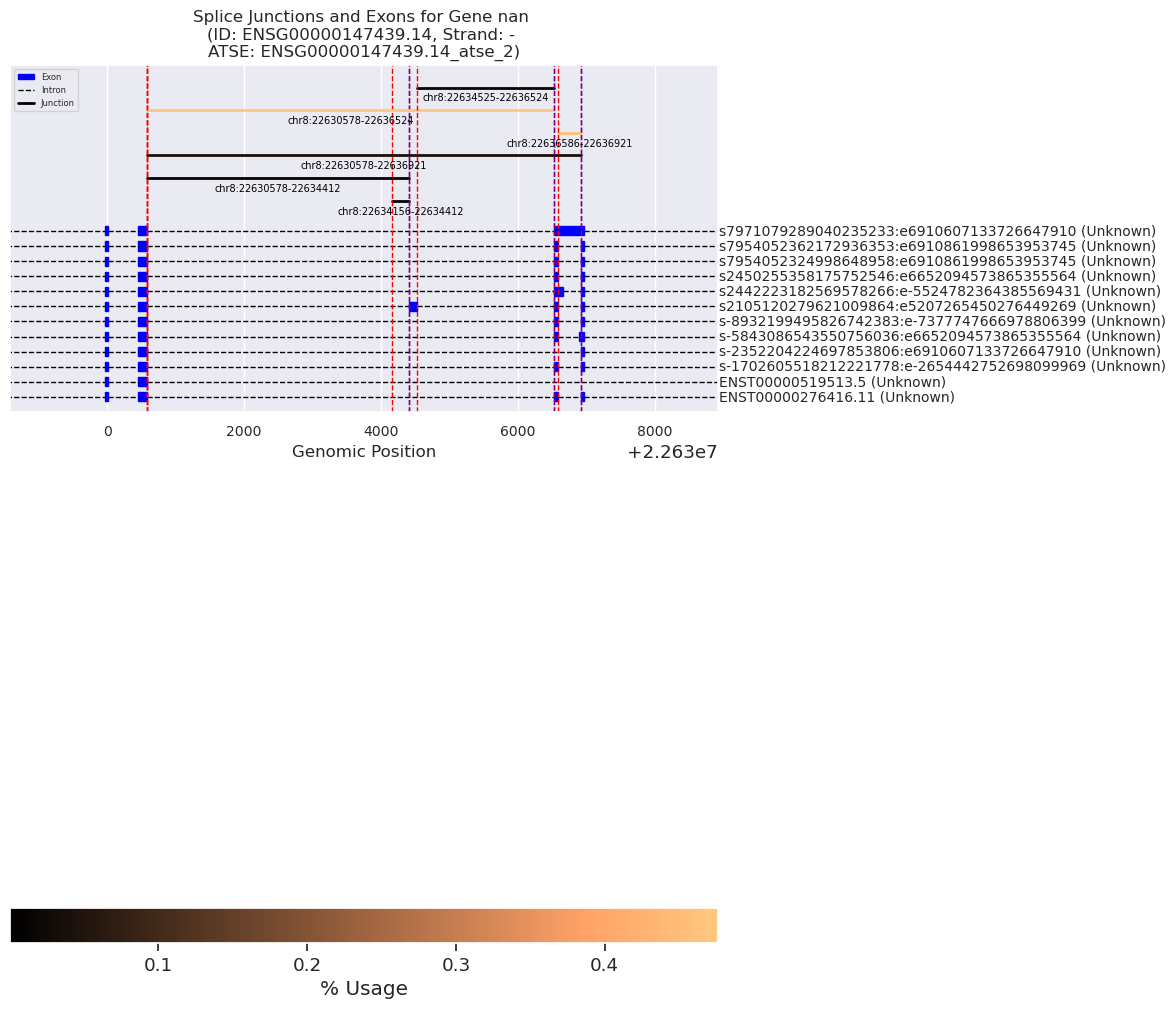

Saved plot to ENSG00000147439.14_atse_2.pdf
Processing ENSG00000147439.14_atse_3...
Found 12 transcripts for ENSG00000147439.14_atse_3
Plot saved to ENSG00000147439.14_atse_3.pdf!


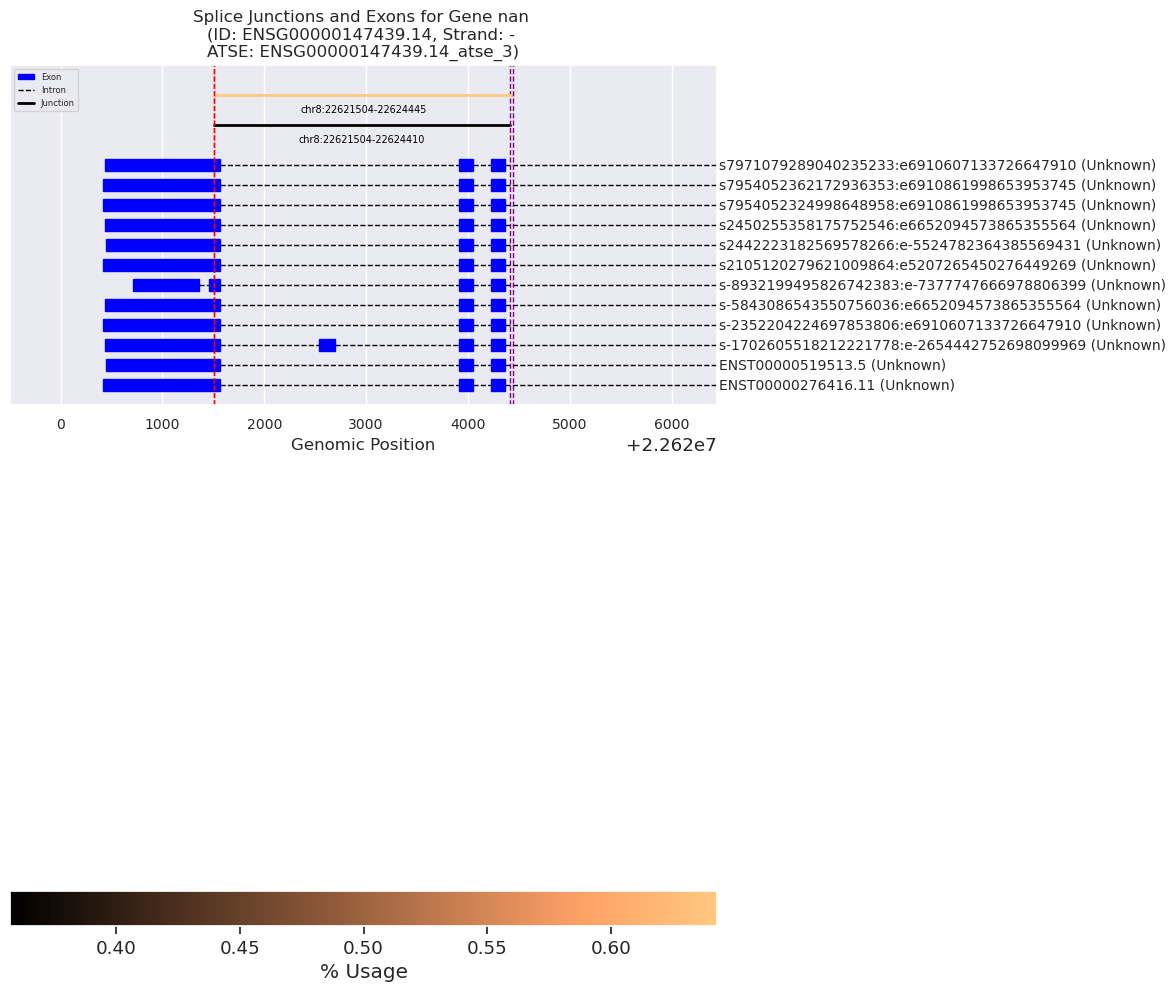

Saved plot to ENSG00000147439.14_atse_3.pdf
Processing ENSG00000147439.14_atse_4...
Found 12 transcripts for ENSG00000147439.14_atse_4
Plot saved to ENSG00000147439.14_atse_4.pdf!


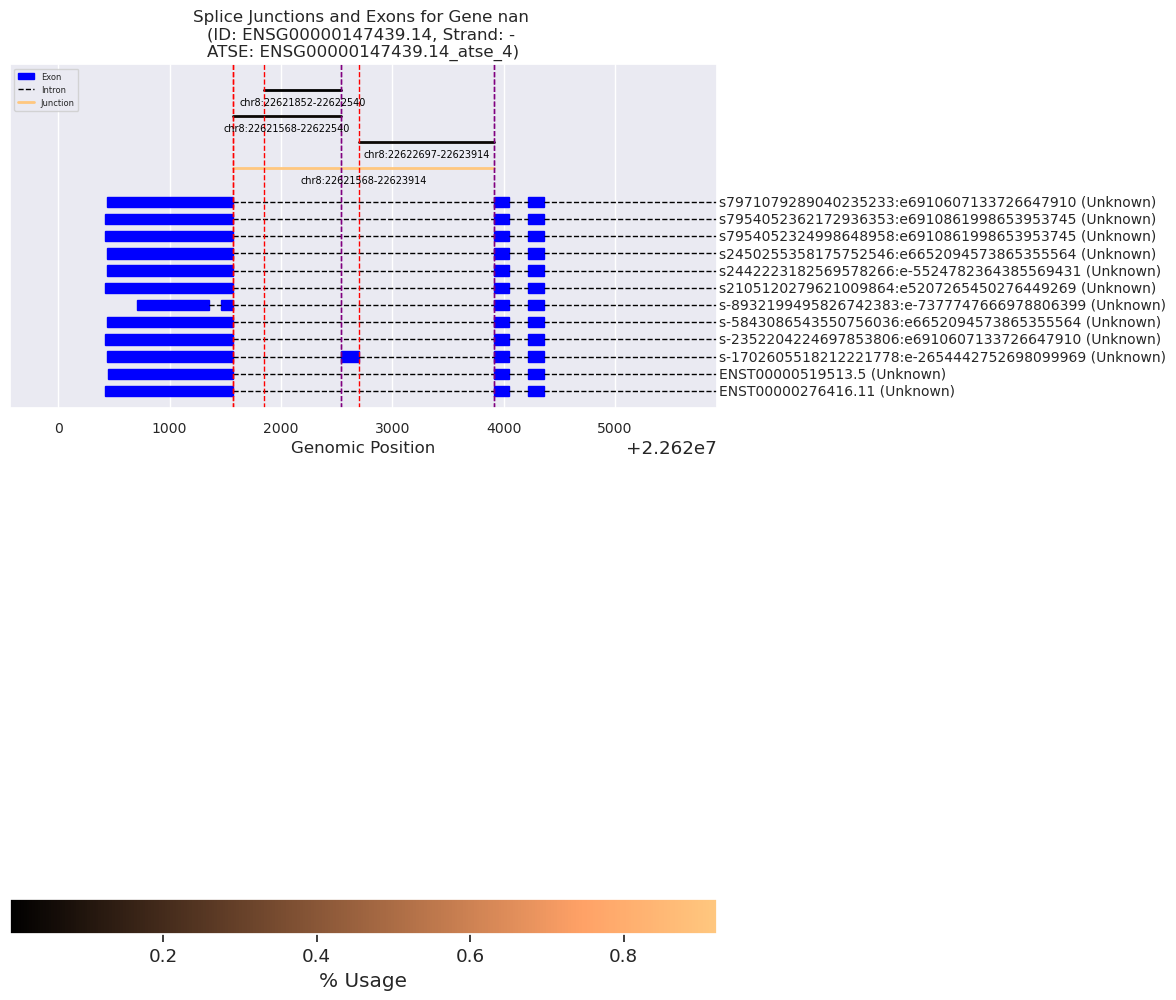

Saved plot to ENSG00000147439.14_atse_4.pdf
Processing ENSG00000147439.14_atse_5...
Found 1 transcripts for ENSG00000147439.14_atse_5
Plot saved to ENSG00000147439.14_atse_5.pdf!


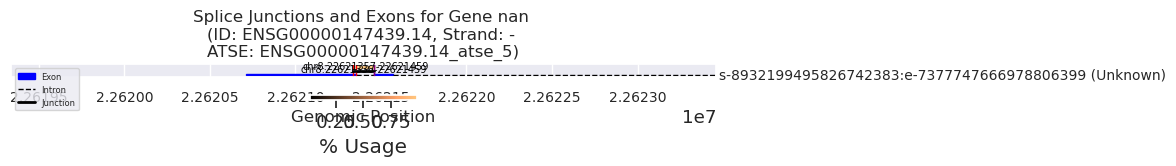

Saved plot to ENSG00000147439.14_atse_5.pdf


In [9]:
# Loop over all unique ATSE event IDs
for atse_event in gene_vals["event_id"].unique():
    print(f"Processing {atse_event}...")

    try:
        # Subset and prepare junctions for this ATSE
        juncs = atses[atses["event_id"] == atse_event].copy()
        if juncs.empty:
            print(f"No junctions found for {atse_event}, skipping.")
            continue

        # Normalize usage_ratio
        total_score_sum = juncs["total_score"].sum()
        if total_score_sum == 0:
            print(f"Total score is zero for {atse_event}, skipping.")
            continue

        juncs.loc[:, "usage_ratio"] = juncs["total_score"] / total_score_sum
        juncs.loc[:, "Cluster"] = juncs["event_id"]

        # Convert junctions to plotting format
        splice_junctions = convert_junction_ids(juncs)

        # Extract associated transcripts
        unique_transcripts = extract_unique_transcripts(juncs)
        if len(unique_transcripts) == 0:
            print(f"No transcripts found for {atse_event}, skipping.")
            continue

        # Fetch transcript annotations
        transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

        # Extract transcript metadata
        conversions = {}
        for t in transcript_data.keys():
            conversions[t] = {
                "transcript_name": transcript_data[t]["transcript_name"],
                "transcript_type": transcript_data[t]["transcript_type"],
                "transcript_id": transcript_data[t]["transcript_id"]
            }

        conversions_df = pd.DataFrame.from_dict(conversions, orient="index")
        print(f"Found {len(conversions_df)} transcripts for {atse_event}")

        # Determine region to plot
        region_start, region_end = determine_region_boundaries(splice_junctions)

        # Output filename per event
        filename = f"{atse_event.replace(':', '_')}.pdf"

        # Plot the event
        plot_exons_and_junctions(
            db,
            atse_event,
            transcript_data,
            splice_junctions,
            region_start-1000,
            region_end+1000,
            base_width=12,
            trans_height=0.8,
            show_usage=True,
            show_junc_lines=True,
            filename=filename
        )

        print(f"Saved plot to {filename}")

    except Exception as e:
        print(f"Error processing {atse_event}: {e}")

# Select junction from dropdown and grey out the transcripts that don't contain it... 
# Something to make it easier to see junction to transcript relationships... 
# Decide if want to show the novel isoforms or not... 
# Github repo for Dashboard to move to knowles lab github repo